# Sample selection and plotting
## Filtering by keys in Catalog
`Catalog` is a class with a `.table` argument, which is always a dataframe. This means, that in order to filter out the catalog we can use any filter function available in pandas. Lets first load the table.


In [1]:
from PTO.database.NASA_exoplanet_archive import NASA_Exoplanet_Archive_CompositeDefault

Catalog = NASA_Exoplanet_Archive_CompositeDefault()
Catalog.load_API_table(force_load=True)

  INFO     | Forced reload:
  INFO     | Accessing NASA Exoplanet Archive
  INFO     | Fetching table
  INFO     | Table fetched successfully
  WARNING  |     Droping all values without errorbars. To instead replace the errorbars with 0 change Catalogs "drop_mode" key to "replace"
  INFO     | Filling in Earth and Jupiter Radius units in the catalog if empty
  INFO     | Filling in semimajor axis over stellar radius ratio in the catalog if empty
  INFO     | Checking for inclination and impact parameters values
  INFO     | Calculation of T_14 and related values
  INFO     | File saved succesfully in:
  INFO     |     /media/chamaeleontis/Observatory_main/Code/observations_transits/PTO/docs/source/saved_files/CatalogComposite.pkl


You can do a quick plot of the full population sample based on whatever parameters you want. For example, to create a population diagram Planet radius vs Orbital period for periods below 50 days:

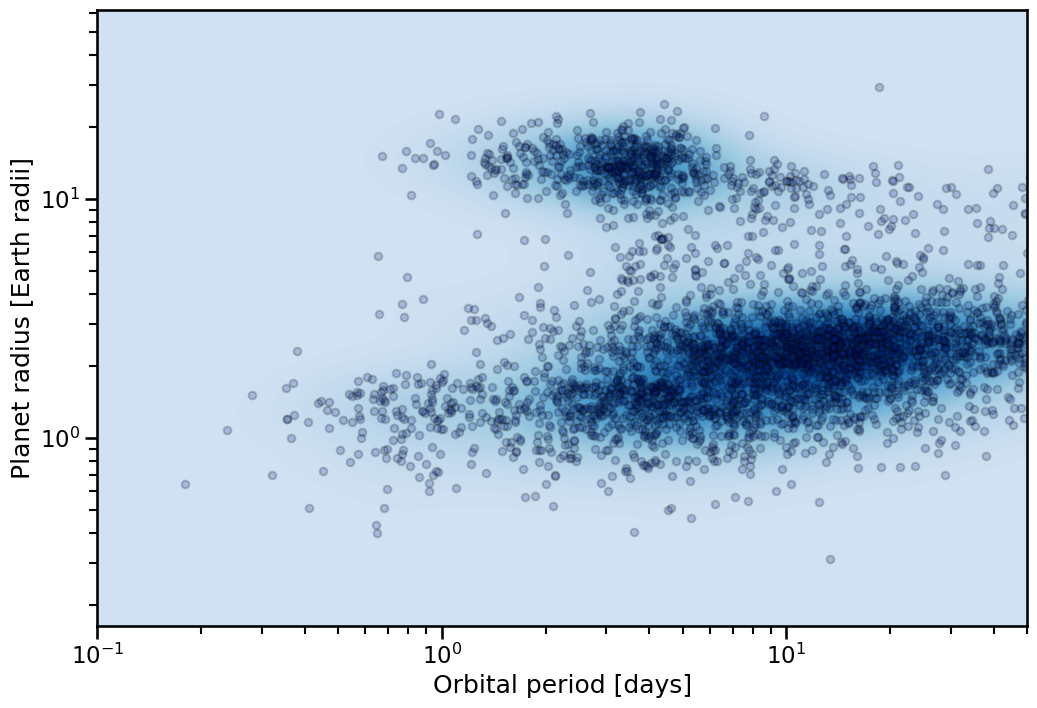

In [2]:
import seaborn as sns
with sns.plotting_context('talk'):
    fig, ax = Catalog.plot_population_diagram(
        x_key= 'Planet.Period',
        y_key= 'Planet.RadiusEarth',
    )
    ax.set_xlim(0.1, 50)


Notice that we can use the standard plotting context on these functions, allowing quick adjustment of the label and legend formats.

## Filtering
Now we can use the `Catalog` class to access the `.table` atribute and work on it. 
For example, to filter out stars with magnitude in V band less than 13:


In [3]:
print(f"Unfiltered length of table: {Catalog.table.shape[0]}")
Catalog.table = Catalog.table[Catalog.table['Magnitude.V'] < 13]
print(f"Filtered length of table: {Catalog.table.shape[0]}")

Unfiltered length of table: 5787
Filtered length of table: 2508


This is the simplest way to filter a table. Other methods will be added. This will not affect the population plots, as the class holds the full infiltered data within a different argument (`legacy_table`), which is used for the plot. We can also reset the table to the full unfiltered sample this way if necessary.

In fact, we can highlight the full sample in the population plot. Lets preselect little more before highlighting the sample.

In [4]:
print(f"Length before further filtering of the table: {Catalog.table.shape[0]}")
Catalog.table = Catalog.table[Catalog.table['Magnitude.V'] < 10]
Catalog.table = Catalog.table[Catalog.table['Planet.RadiusEarth'] > 3]
Catalog.table = Catalog.table[Catalog.table['Planet.RadiusEarth'] < 8]
Catalog.table = Catalog.table[Catalog.table['Planet.Period'] < 30]
print(f"Length after further filtering of the table: {Catalog.table.shape[0]}")

Length before further filtering of the table: 2508
Length after further filtering of the table: 31


(0.1, 50)

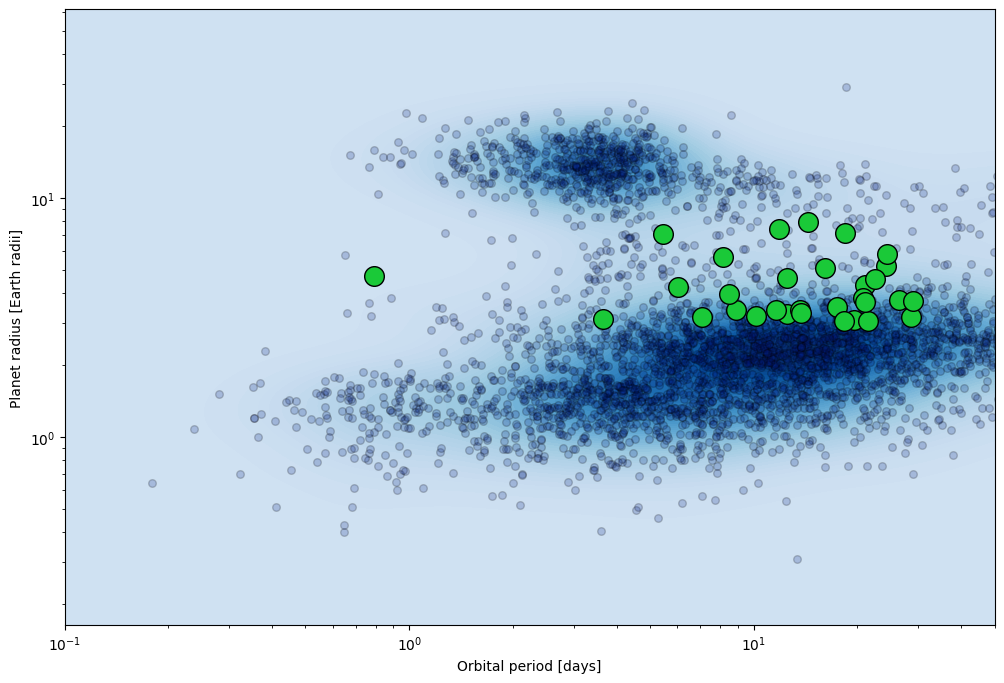

In [5]:
fig, ax = Catalog.highlight_sample(
    x_key= 'Planet.Period',
    y_key= 'Planet.RadiusEarth',
)
ax.set_xlim(0.1,50)

## Themes
Each plot has multiple themes to use. These are generally single color dominated. To access list of viable colors:


In [6]:
themes = Catalog.available_themes()

  PRINT    | =========================
  PRINT    | Printing themes for the plot_diagram() method
  INFO     | red
  INFO     | blue
  INFO     | green
  INFO     | grayscale
  INFO     | purple
  PRINT    | =========================


The resulting plots look like:


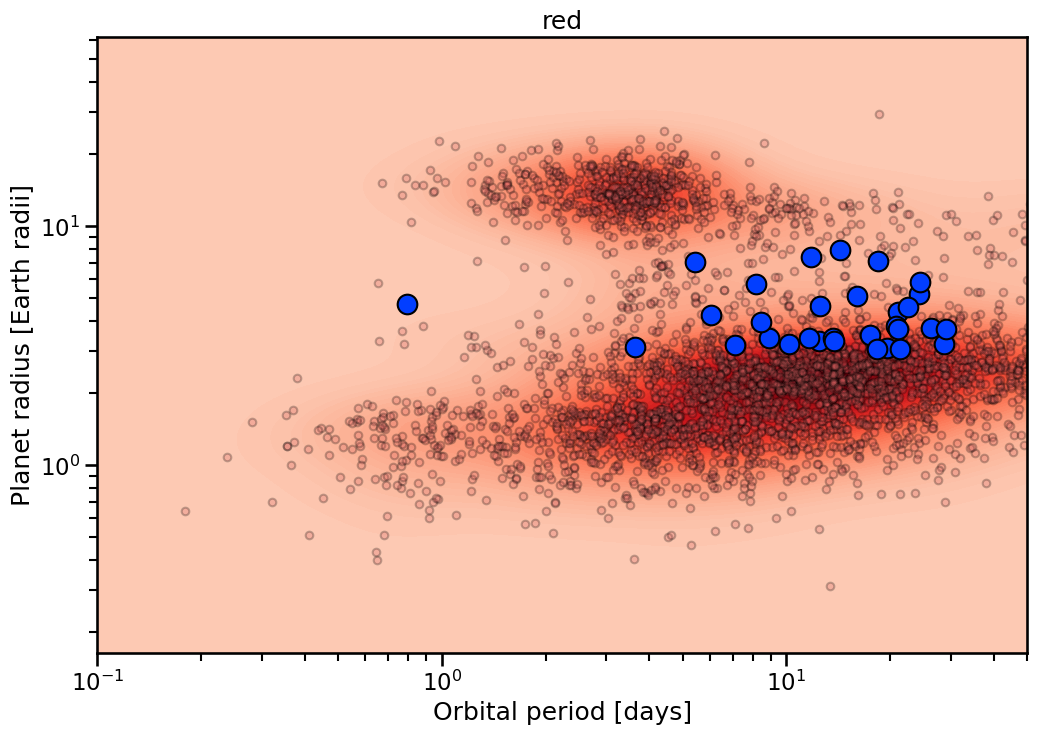

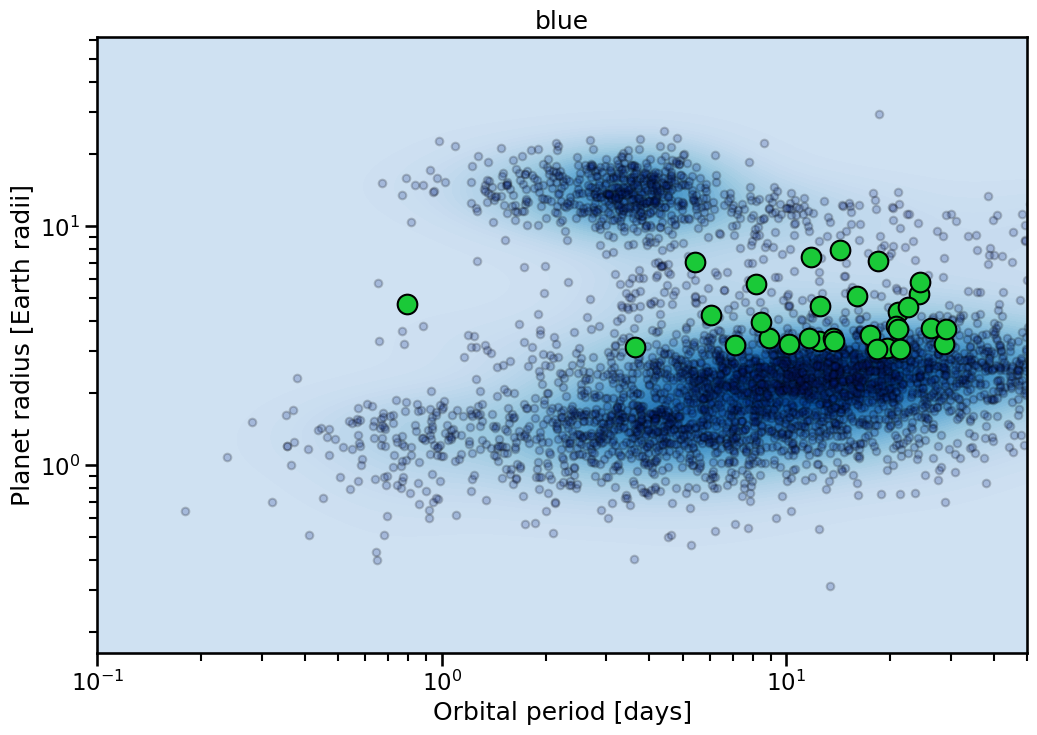

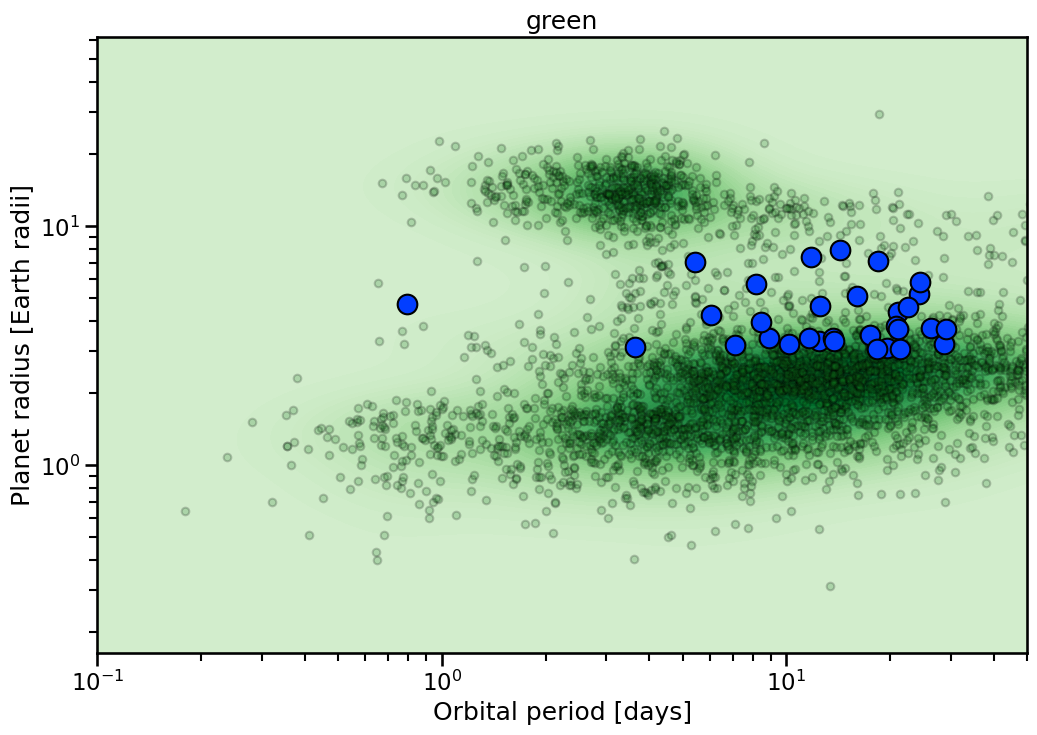

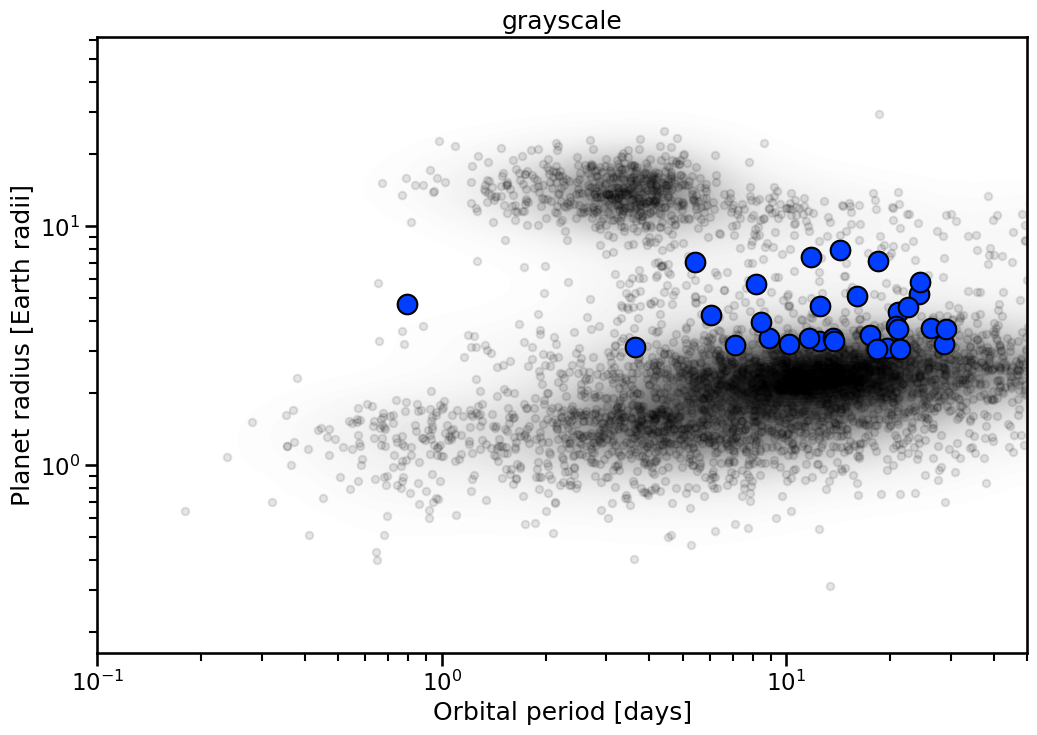

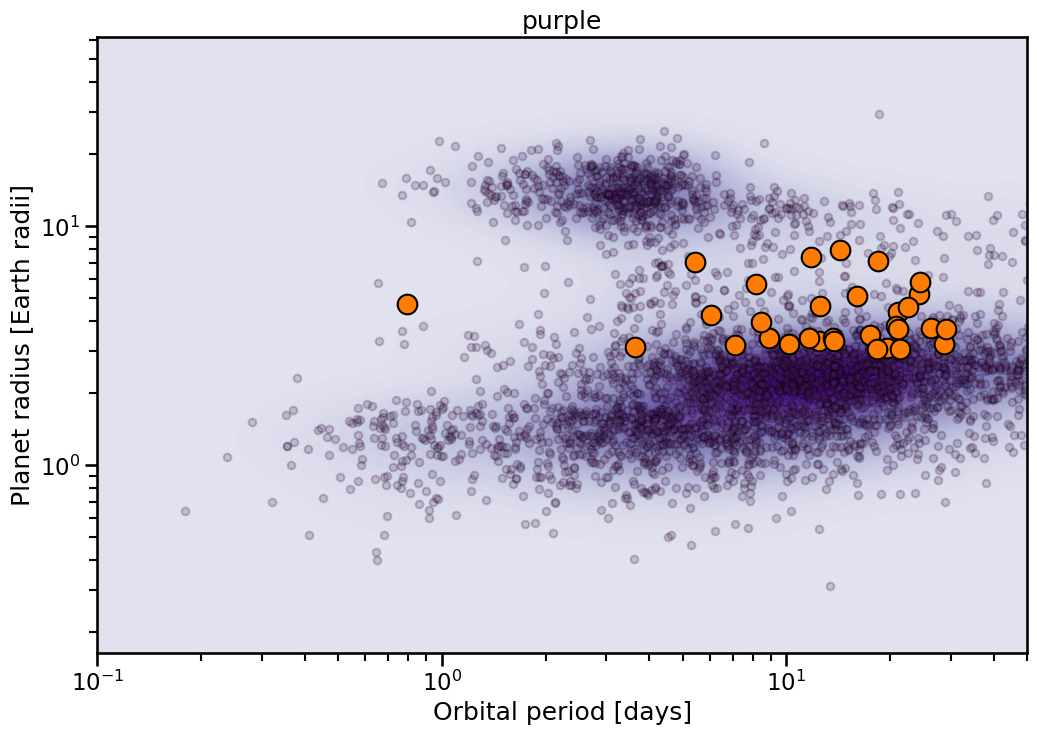

In [7]:
for theme in themes:
    with sns.plotting_context('talk'):
        fig, ax = Catalog.highlight_sample(
            x_key= 'Planet.Period',
            y_key= 'Planet.RadiusEarth',
            theme= theme,
        )
        ax.set_xlim(0.1,50)
        ax.set_title(theme)